# 🫀 CardioRisk — No-Blood-Test CVD Screening  
## Complete Pipeline: EDA → 3 Models → Comparison → Best Model → GUI

This notebook implements a clean, reproducible, and academically structured machine learning workflow for predicting cardiovascular disease (CVD) using non-invasive clinical features.

### Sections
| Section | Cells | Purpose |
|---|---:|---|
| Setup | 1–3 | Environment, data path, loading |
| Data | 4–6 | Cleaning, inspection, feature engineering |
| EDA | 7–8 | Exploratory visualization and descriptive analysis |
| Modelling | 9–11 | Train/test split, compare 3 models, tuning |
| Evaluation | 12–15 | Metrics, thresholds, calibration, plots |
| Explainability | 16–17 | Risk deciles and SHAP interpretation |
| Deployment | 18–20 | Save model, generate GUI, launch instructions |

### Models Compared
- **Logistic Regression** — interpretable linear baseline  
- **Random Forest** — robust ensemble of trees  
- **HistGradientBoosting** — efficient boosting model with strong tabular performance

⚠️ **Research use only.** This notebook does **not** replace clinical assessment or diagnostic testing.

## Cell 1 — Install dependencies and import libraries

This section initializes the analytical environment, imports all required libraries, and prints key package versions for reproducibility.

In [1]:
# Uncomment if needed in a fresh environment
# !pip install shap ipywidgets flask --quiet

import sys
import time
import json
import pickle
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

SEED = 42
np.random.seed(SEED)

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
logger = logging.getLogger("CardioRisk")

print("=" * 60)
print(" CardioRisk v4 Clean — Environment")
print("=" * 60)
print(f" Python        : {sys.version.split()[0]}")
print(f" NumPy         : {np.__version__}")
print(f" Pandas        : {pd.__version__}")
print(f" Scikit-learn  : {__import__('sklearn').__version__}")
print(f" SHAP          : {shap.__version__}")
print("=" * 60)

 CardioRisk v4 Clean — Environment
 Python        : 3.14.3
 NumPy         : 2.4.3
 Pandas        : 3.0.1
 Scikit-learn  : 1.8.0
 SHAP          : 0.51.0


## Cell 2 — Define project paths

The project uses relative paths for portability. The expected dataset location is:

`data/cardio_train_augmented.csv`

In [2]:
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "cardio_train_augmented.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at: {DATA_PATH.resolve()}"
print("Dataset path:", DATA_PATH.resolve())
print("Output path :", OUTPUT_DIR.resolve())

Dataset path: C:\Users\hp\Downloads\PROJECT\data\cardio_train_augmented.csv
Output path : C:\Users\hp\Downloads\PROJECT\outputs


## Cell 3 — Load and inspect the raw dataset

The raw file is loaded and basic dataset properties are displayed, including shape, column names, target balance, and missing-value summary.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns : {list(df_raw.columns)}")

print("\nTarget distribution:")
print(df_raw["cardio"].value_counts().rename({0: "No CVD", 1: "CVD"}).to_string())

print("\nMissing values:")
miss = df_raw.isnull().sum()
print(miss[miss > 0].to_string() if miss.sum() > 0 else "None")

display(df_raw.head())
display(df_raw.describe(include="all").transpose().head(20))

Shape   : 70,000 rows × 20 columns
Columns : ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'DATE_OF_BIRTH', 'DATE_OF_DIAGNOSIS', 'DATE_OF_DEATH', 'VITAL_STATUS', 'FOLLOW_UP_DAYS', 'EVENT', 'ETHNICITY']

Target distribution:
cardio
No CVD    35021
CVD       34979

Missing values:
DATE_OF_DEATH    50312
ETHNICITY         2021


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,DATE_OF_BIRTH,DATE_OF_DIAGNOSIS,DATE_OF_DEATH,VITAL_STATUS,FOLLOW_UP_DAYS,EVENT,ETHNICITY
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,1975-11-27,2024-12-01,NaN,Alive,462,0,Western European
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1970-10-21,2022-11-12,2023-11-24,Dead,377,1,Pakistani
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,1974-08-16,2023-03-23,2024-07-30,Dead,495,1,Bangladeshi
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1978-01-02,2023-11-14,NaN,Alive,845,0,British
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,1978-05-09,2023-11-20,NaN,Alive,839,0,White British


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,70000.0,NaN,NaN,NaN,49972.4199,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,NaN,NaN,NaN,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
gender,70000.0,NaN,NaN,NaN,1.349571,0.476838,1.0,1.0,1.0,2.0,2.0
height,70000.0,NaN,NaN,NaN,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,NaN,NaN,NaN,74.20569,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,NaN,NaN,NaN,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,NaN,NaN,NaN,96.630414,188.47253,-70.0,80.0,80.0,90.0,11000.0
cholesterol,70000.0,NaN,NaN,NaN,1.366871,0.68025,1.0,1.0,1.0,2.0,3.0
gluc,70000.0,NaN,NaN,NaN,1.226457,0.57227,1.0,1.0,1.0,1.0,3.0
smoke,70000.0,NaN,NaN,NaN,0.088129,0.283484,0.0,0.0,0.0,0.0,1.0


## Cell 4 — Data cleaning

Two-stage cleaning is applied:

1. **Clinical plausibility bounds** remove physiologically impossible or clearly erroneous entries.  
2. **1st–99th percentile trimming** reduces subtle extreme values that pass the first filter.

This keeps the cleaning strategy clinically defensible while preserving the main data structure.

In [4]:
def load_and_clean(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    n0 = len(df)
    logger.info(f"Raw rows: {n0:,}")

    # Stage 1 — Clinical plausibility bounds
    mask = (
        df["ap_hi"].between(70, 250) &
        df["ap_lo"].between(40, 200) &
        df["height"].between(100, 220) &
        df["weight"].between(30, 250) &
        (df["ap_hi"] > df["ap_lo"])
    )
    df = df[mask].copy()
    n1 = len(df)
    logger.info(f"After clinical filters: {n1:,} (removed {n0 - n1:,})")

    # Stage 2 — 1st–99th percentile trimming
    for col in ["ap_hi", "ap_lo", "height", "weight"]:
        q_low, q_high = df[col].quantile(0.01), df[col].quantile(0.99)
        df = df[(df[col] >= q_low) & (df[col] <= q_high)]

    n2 = len(df)
    logger.info(f"After percentile trimming: {n2:,} (removed {n1 - n2:,})")

    return df.reset_index(drop=True)

df = load_and_clean(DATA_PATH)

vc = df["cardio"].value_counts(normalize=True).sort_index()
print(f"\nFinal rows  : {len(df):,}")
print(f"No CVD (0)  : {vc.loc[0]:.1%}")
print(f"CVD (1)     : {vc.loc[1]:.1%}")
print(f"Missing     : {df.isnull().sum().sum():,}")

display(df[["height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc"]].describe().round(2))

INFO - Raw rows: 70,000
INFO - After clinical filters: 68,638 (removed 1,362)
INFO - After percentile trimming: 65,249 (removed 3,389)



Final rows  : 65,249
No CVD (0)  : 51.0%
CVD (1)     : 49.0%
Missing     : 48,878


,height,weight,ap_hi,ap_lo,cholesterol,gluc
count,65249.00,65249.00,65249.00,65249.00,65249.00,65249.00
mean,164.46,73.66,126.10,81.01,1.36,1.22
std,7.29,12.75,15.52,8.69,0.67,0.57
min,147.00,48.00,90.00,60.00,1.00,1.00
25%,159.00,65.00,120.00,80.00,1.00,1.00
50%,165.00,72.00,120.00,80.00,1.00,1.00
75%,170.00,81.00,140.00,90.00,1.00,1.00
max,184.00,115.00,180.00,100.00,3.00,3.00


## Cell 5 — Feature engineering

Feature engineering is guided by cardiovascular risk logic rather than arbitrary polynomial expansion.

### Derived features
- `age_years` — convert age from days to years  
- `bmi` — body mass index  
- `pulse_pressure` — systolic minus diastolic pressure  
- `map` — mean arterial pressure  
- `hyp_flag` — hypertension indicator  
- `metabolic_score` — obesity/glucose/cholesterol composite  
- `risk_count` — simple clinical risk counter  
- `age_x_ap_hi` — age-amplified blood pressure risk  
- `bmi_inactive` — sedentary obesity interaction

In [5]:
def engineer_features(df: pd.DataFrame):
    df = df.copy()

    df["age_years"] = df["age"] / 365.0
    df["bmi"] = df["weight"] / ((df["height"] / 100.0) ** 2)
    df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

    df["map"] = df["ap_lo"] + df["pulse_pressure"] / 3.0
    df["hyp_flag"] = (df["ap_hi"] >= 140).astype(float)

    df["metabolic_score"] = (
        (df["bmi"] >= 30).astype(int) +
        (df["gluc"] > 1).astype(int) +
        (df["cholesterol"] > 1).astype(int)
    ).astype(float)

    df["risk_count"] = (
        (df["ap_hi"] >= 140).astype(int) +
        (df["age_years"] >= 55).astype(int) +
        (df["cholesterol"] == 3).astype(int) +
        (df["bmi"] >= 30).astype(int) +
        (df["active"] == 0).astype(int)
    ).astype(float)

    df["age_x_ap_hi"] = df["age_years"] * (df["ap_hi"] / 120.0)
    df["bmi_inactive"] = df["bmi"] * (1.0 - df["active"])

    features = [
        "age_years", "bmi", "ap_hi", "ap_lo", "pulse_pressure",
        "cholesterol", "gluc", "smoke", "alco", "active", "gender",
        "map", "hyp_flag", "metabolic_score", "risk_count",
        "age_x_ap_hi", "bmi_inactive"
    ]
    return df, features

df, FEATURES = engineer_features(df)
TARGET = "cardio"

print(f"Total engineered feature count: {len(FEATURES)}")
for f in FEATURES:
    s = df[f]
    print(f"{f:<18} min={s.min():>8.2f} max={s.max():>8.2f} mean={s.mean():>8.2f}")

print("\nMissing values within feature matrix:", int(df[FEATURES].isnull().sum().sum()))

Total engineered feature count: 17
age_years          min=   29.58 max=   64.97 mean=   53.33
bmi                min=   15.09 max=   50.90 mean=   27.28
ap_hi              min=   90.00 max=  180.00 mean=  126.10
ap_lo              min=   60.00 max=  100.00 mean=   81.01
pulse_pressure     min=    5.00 max=  120.00 mean=   45.09
cholesterol        min=    1.00 max=    3.00 mean=    1.36
gluc               min=    1.00 max=    3.00 mean=    1.22
smoke              min=    0.00 max=    1.00 mean=    0.09
alco               min=    0.00 max=    1.00 mean=    0.05
active             min=    0.00 max=    1.00 mean=    0.80
gender             min=    1.00 max=    2.00 mean=    1.35
map                min=   70.00 max=  126.67 mean=   96.04
hyp_flag           min=    0.00 max=    1.00 mean=    0.26
metabolic_score    min=    0.00 max=    3.00 mean=    0.64
risk_count         min=    0.00 max=    5.00 mean=    1.26
age_x_ap_hi        min=   24.65 max=   97.05 mean=   56.23
bmi_inactive       mi

## Cell 6 — Project summary table

This compact summary provides a structured overview of the cleaned dataset, target balance, and engineered feature set before visualization and modelling.

In [6]:
summary_table = pd.DataFrame({
    "Item": [
        "Raw rows", "Clean rows", "Target prevalence (CVD)", "Number of features",
        "Blood pressure cleaning", "Feature engineering style", "Random seed"
    ],
    "Value": [
        f"{len(df_raw):,}",
        f"{len(df):,}",
        f"{df[TARGET].mean():.1%}",
        len(FEATURES),
        "Clinical bounds + percentile trimming",
        "Clinically motivated composites",
        SEED
    ]
})
display(summary_table)

,Item,Value
0,Raw rows,"70,000"
1,Clean rows,"65,249"
2,Target prevalence (CVD),49.0%
3,Number of features,17
4,Blood pressure cleaning,Clinical bounds + percentile trimming
5,Feature engineering style,Clinically motivated composites
6,Random seed,42


## Cell 7 — Exploratory data analysis

The following panels provide a high-level visual inspection of risk patterns across age, systolic blood-pressure stage, cholesterol category, and feature correlations.

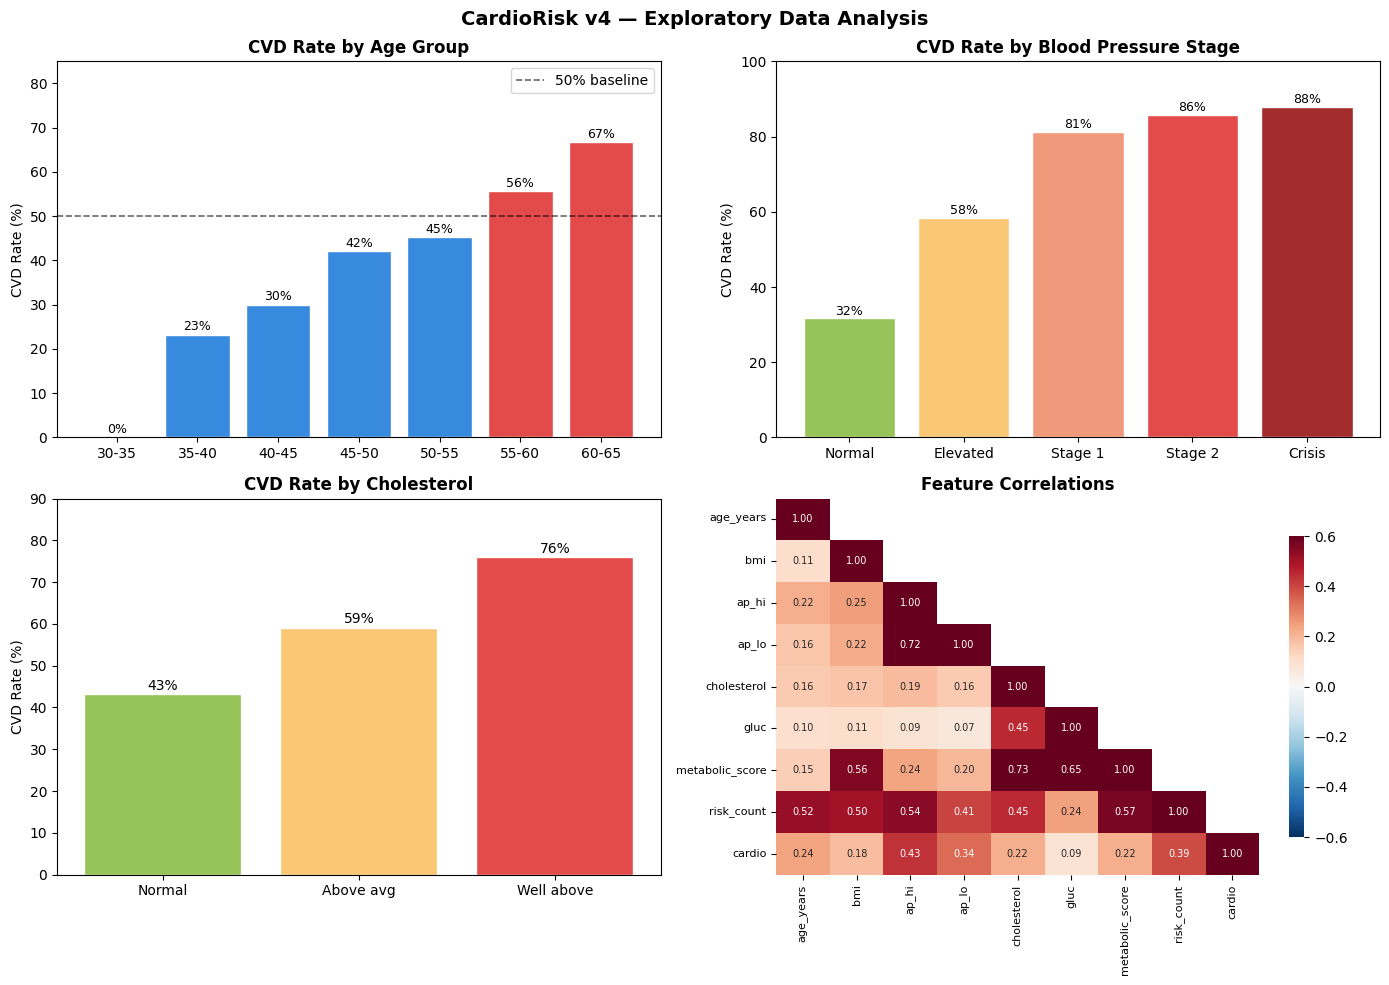

Saved: outputs\eda_plots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CardioRisk v4 — Exploratory Data Analysis", fontsize=14, fontweight="bold")

# 1. CVD rate by age group
ax = axes[0, 0]
df["_age_grp"] = pd.cut(
    df["age_years"],
    bins=[29, 35, 40, 45, 50, 55, 60, 66],
    labels=["30-35", "35-40", "40-45", "45-50", "50-55", "55-60", "60-65"]
)
rates = df.groupby("_age_grp", observed=True)["cardio"].mean() * 100
colors = ["#378ADD" if v < 50 else "#E24B4A" for v in rates.values]
bars = ax.bar(rates.index, rates.values, color=colors, edgecolor="white")
ax.axhline(50, color="black", ls="--", lw=1.2, alpha=0.6, label="50% baseline")
ax.set_title("CVD Rate by Age Group", fontweight="bold")
ax.set_ylabel("CVD Rate (%)")
ax.set_ylim(0, 85)
ax.legend()
for b, v in zip(bars, rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

# 2. CVD rate by systolic BP stage
ax = axes[0, 1]
df["_bp"] = pd.cut(
    df["ap_hi"],
    bins=[0, 120, 130, 140, 160, 300],
    labels=["Normal", "Elevated", "Stage 1", "Stage 2", "Crisis"]
)
bp_rates = df.groupby("_bp", observed=True)["cardio"].mean() * 100
bp_colors = ["#97C459", "#FAC775", "#F0997B", "#E24B4A", "#A32D2D"]
bars2 = ax.bar(bp_rates.index, bp_rates.values, color=bp_colors, edgecolor="white")
ax.set_title("CVD Rate by Blood Pressure Stage", fontweight="bold")
ax.set_ylabel("CVD Rate (%)")
ax.set_ylim(0, 100)
for b, v in zip(bars2, bp_rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

# 3. CVD rate by cholesterol
ax = axes[1, 0]
chol_map = {1: "Normal", 2: "Above avg", 3: "Well above"}
chol_r = df.groupby("cholesterol")["cardio"].mean() * 100
bars3 = ax.bar([chol_map[i] for i in chol_r.index], chol_r.values,
               color=["#97C459", "#FAC775", "#E24B4A"], edgecolor="white")
ax.set_title("CVD Rate by Cholesterol", fontweight="bold")
ax.set_ylabel("CVD Rate (%)")
ax.set_ylim(0, 90)
for b, v in zip(bars3, chol_r.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%", ha="center", fontsize=10)

# 4. Correlation heatmap
ax = axes[1, 1]
subset = ["age_years", "bmi", "ap_hi", "ap_lo", "cholesterol", "gluc",
          "metabolic_score", "risk_count", "cardio"]
corr = df[subset].corr(numeric_only=True)
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
    ax=ax, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8}
)
ax.set_title("Feature Correlations", fontweight="bold")
ax.tick_params(labelsize=8)

df.drop(columns=["_age_grp", "_bp"], inplace=True, errors="ignore")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "eda_plots.png")

## Cell 8 — Distribution diagnostics

These plots inspect the distributions of the most clinically relevant continuous variables after cleaning and feature engineering.

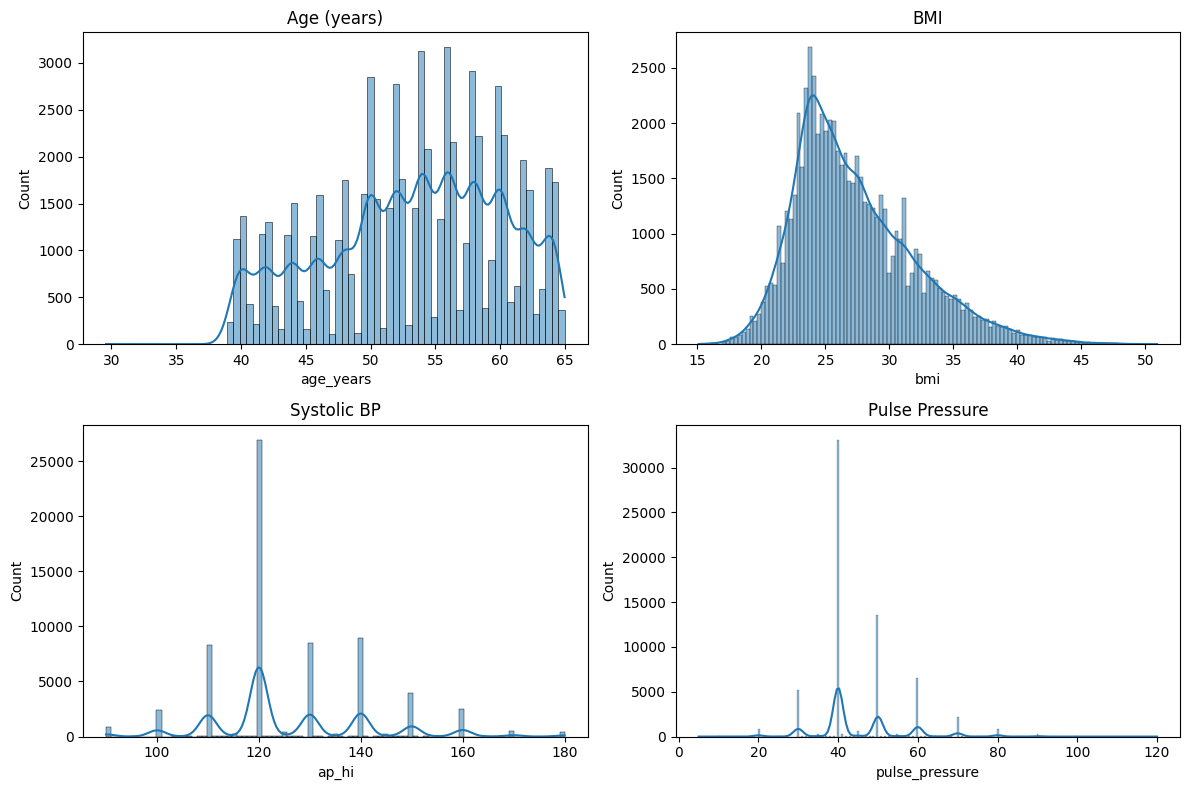

Saved: outputs\distribution_plots.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["age_years"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age (years)")

sns.histplot(df["bmi"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("BMI")

sns.histplot(df["ap_hi"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Systolic BP")

sns.histplot(df["pulse_pressure"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Pulse Pressure")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribution_plots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "distribution_plots.png")

## Cell 9 — Train/test split

A stratified 80/20 split is used to preserve class balance across the train and test sets.

In [9]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print("=" * 52)
print(" Train / Test Split")
print("=" * 52)
print(f" Total    : {len(X):>7,} (CVD: {y.mean():.1%})")
print(f" Train    : {len(X_train):>7,} (CVD: {y_train.mean():.1%})")
print(f" Test     : {len(X_test):>7,} (CVD: {y_test.mean():.1%})")
print(f" Features : {len(FEATURES)}")
print("=" * 52)

 Train / Test Split
 Total    :  65,249 (CVD: 49.0%)
 Train    :  52,199 (CVD: 49.0%)
 Test     :  13,050 (CVD: 49.0%)
 Features : 17


## Cell 10 — Train and compare three models

Three models are benchmarked under the same stratified cross-validation protocol.

### Important implementation choices
- **StandardScaler is applied only to Logistic Regression**
- **Tree-based models are not scaled**
- **HistGradientBoostingClassifier is used directly**, rather than importing it and then evaluating a different boosting model

In [10]:
MODELS = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000, C=1.0, solver="lbfgs", random_state=SEED
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=8,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.04,
        max_iter=300,
        max_depth=4,
        min_samples_leaf=20,
        random_state=SEED
    ),
}

print("Running 5-fold CV on 3 models...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model in MODELS.items():
    t0 = time.time()
    aucs = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    accs = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = {
        "auc_mean": aucs.mean(),
        "auc_std": aucs.std(),
        "acc_mean": accs.mean(),
        "acc_std": accs.std(),
    }
    print(
        f"{name:<22} AUC {aucs.mean():.4f} ± {aucs.std():.4f}"
        f" | Acc {accs.mean():.4f} ({time.time() - t0:.0f}s)"
    )

ranked = sorted(cv_results.items(), key=lambda x: x[1]["auc_mean"], reverse=True)
BEST_MODEL_NAME = ranked[0][0]

print()
print("=" * 72)
print(f"{'Model':<25} {'CV AUC':>9} {'±':>7} {'CV Acc':>9} Rank")
print("=" * 72)
for rank, (name, r) in enumerate(ranked, 1):
    star = " ← SELECTED" if rank == 1 else ""
    print(f"{name:<25} {r['auc_mean']:>9.4f} {r['auc_std']:>7.4f} {r['acc_mean']:>9.4f} #{rank}{star}")
print("=" * 72)

print("\nFitting all models on full training set...")
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    print(f"✓ {name}")

pipeline = MODELS[BEST_MODEL_NAME]
print(f"\nBest model selected: {BEST_MODEL_NAME}")

Running 5-fold CV on 3 models...
Logistic Regression    AUC 0.7933 ± 0.0042 | Acc 0.7285 (1s)
Random Forest          AUC 0.7976 ± 0.0042 | Acc 0.7337 (22s)
HistGradientBoosting   AUC 0.7984 ± 0.0046 | Acc 0.7334 (8s)

Model                        CV AUC       ±    CV Acc Rank
HistGradientBoosting         0.7984  0.0046    0.7334 #1 ← SELECTED
Random Forest                0.7976  0.0042    0.7337 #2
Logistic Regression          0.7933  0.0042    0.7285 #3

Fitting all models on full training set...
✓ Logistic Regression
✓ Random Forest
✓ HistGradientBoosting

Best model selected: HistGradientBoosting


## Cell 11 — Hyperparameter tuning for the selected model

A focused grid search is applied only to the winning model. The tuned version is adopted only if it produces a meaningful cross-validated AUC gain.

In [11]:
PARAM_GRIDS = {
    "Logistic Regression": {
        "model__C": [0.1, 0.3, 1.0, 3.0, 10.0],
        "model__solver": ["lbfgs", "saga"],
    },
    "Random Forest": {
        "n_estimators": [300, 500],
        "max_depth": [10, 12, 16],
        "min_samples_leaf": [5, 8, 12],
    },
    "HistGradientBoosting": {
        "learning_rate": [0.03, 0.04, 0.06],
        "max_depth": [3, 4, 5],
        "max_iter": [200, 300, 400],
    },
}

print(f"Tuning {BEST_MODEL_NAME}...")
base_model = MODELS[BEST_MODEL_NAME]

grid_search = GridSearchCV(
    base_model,
    PARAM_GRIDS[BEST_MODEL_NAME],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    verbose=0,
)

grid_search.fit(X_train, y_train)

before_auc = cv_results[BEST_MODEL_NAME]["auc_mean"]
after_auc = grid_search.best_score_

print(f"Before tuning CV AUC : {before_auc:.4f}")
print(f"After tuning CV AUC  : {after_auc:.4f}")
print(f"Gain                 : {after_auc - before_auc:+.4f}")
print(f"Best params          : {grid_search.best_params_}")

if after_auc > before_auc + 0.0005:
    pipeline = grid_search.best_estimator_
    print("Tuned model selected.")
else:
    print("Gain < 0.0005 — original model retained.")

Tuning HistGradientBoosting...
Before tuning CV AUC : 0.7984
After tuning CV AUC  : 0.7987
Gain                 : +0.0002
Best params          : {'learning_rate': 0.06, 'max_depth': 3, 'max_iter': 200}
Gain < 0.0005 — original model retained.


## Cell 12 — Full evaluation and optimal threshold search

The selected model is evaluated on the held-out test set. In addition to default threshold performance, a threshold search is performed over the interval **0.30–0.70**.

In [12]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

auc_score = roc_auc_score(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

cm_50 = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm_50.ravel()

best_acc, best_t = 0.0, 0.50
for t in np.arange(0.30, 0.701, 0.005):
    acc_t = accuracy_score(y_test, (y_proba >= t).astype(int))
    if acc_t > best_acc:
        best_acc, best_t = acc_t, t

OPT_THRESHOLD = float(best_t)
cm_opt = confusion_matrix(y_test, (y_proba >= OPT_THRESHOLD).astype(int))

print("=" * 64)
print(" Final Evaluation — Held-Out Test Set")
print("=" * 64)
print(f"Rows evaluated          : {len(y_test):,}")
print(f"ROC-AUC                 : {auc_score:.4f}")
print(f"Average Precision       : {avg_prec:.4f}")
print(f"Brier Score             : {brier:.4f}")
print(f"\nAt t=0.50 (default):")
print(f"Accuracy                : {(tp+tn)/len(y_test):.4f}")
print(f"Sensitivity             : {tp/(tp+fn):.4f}")
print(f"Specificity             : {tn/(tn+fp):.4f}")
print(f"PPV                     : {tp/(tp+fp):.4f}")
print(f"NPV                     : {tn/(tn+fn):.4f}")
print(f"\nAccuracy-optimal threshold: t={OPT_THRESHOLD:.3f}")
print(f"Optimal accuracy        : {best_acc:.4f}")
print("=" * 64)

print(classification_report(y_test, y_pred, target_names=["No CVD", "CVD"]))

print("Clinical threshold table:")
print(f"{'t':>6} {'Sensitivity':>12} {'Specificity':>12} {'PPV':>8} {'Accuracy':>10} Use case")
for t, use in [(0.35, "screening"), (0.40, "balanced"), (0.50, "default"),
               (round(OPT_THRESHOLD, 2), "optimal ACC"), (0.60, "referral")]:
    p = (y_proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, p).ravel()
    s = tp_t / (tp_t + fn_t)
    sp = tn_t / (tn_t + fp_t)
    pv = tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0.0
    ac = (tp_t + tn_t) / len(y_test)
    print(f"{t:6.3f} {s:12.3f} {sp:12.3f} {pv:8.3f} {ac:10.4f} {use}")

 Final Evaluation — Held-Out Test Set
Rows evaluated          : 13,050
ROC-AUC                 : 0.8003
Average Precision       : 0.7790
Brier Score             : 0.1808

At t=0.50 (default):
Accuracy                : 0.7323
Sensitivity             : 0.6848
Specificity             : 0.7779
PPV                     : 0.7477
NPV                     : 0.7197

Accuracy-optimal threshold: t=0.465
Optimal accuracy        : 0.7343
              precision    recall  f1-score   support

      No CVD       0.72      0.78      0.75      6654
         CVD       0.75      0.68      0.71      6396

    accuracy                           0.73     13050
   macro avg       0.73      0.73      0.73     13050
weighted avg       0.73      0.73      0.73     13050

Clinical threshold table:
     t  Sensitivity  Specificity      PPV   Accuracy Use case
 0.350        0.835        0.581    0.657     0.7051 screening
 0.400        0.779        0.673    0.696     0.7251 balanced
 0.500        0.685        0.778 

## Cell 13 — Probability calibration

Probability calibration is evaluated using isotonic regression. The calibrated model is assessed with ROC-AUC and Brier score to quantify ranking quality and probability quality.

In [13]:
calibrated_model = CalibratedClassifierCV(pipeline, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

cal_proba = calibrated_model.predict_proba(X_test)[:, 1]
auc_cal = roc_auc_score(y_test, cal_proba)
brier_cal = brier_score_loss(y_test, cal_proba)

print("=" * 52)
print(" Probability Calibration")
print("=" * 52)
print(f"Raw model      : AUC {auc_score:.4f} | Brier {brier:.4f}")
print(f"Calibrated     : AUC {auc_cal:.4f} | Brier {brier_cal:.4f}")
print(f"AUC change     : {auc_cal - auc_score:+.4f}")
print(f"Brier gain     : {brier - brier_cal:+.4f} (positive = better)")
print("=" * 52)

CALIBRATOR = calibrated_model

 Probability Calibration
Raw model      : AUC 0.8003 | Brier 0.1808
Calibrated     : AUC 0.8000 | Brier 0.1811
AUC change     : -0.0003
Brier gain     : -0.0003 (positive = better)


## Cell 14 — Evaluation plots

This section visualizes ROC performance across all three models, compares test and cross-validation AUC, shows the confusion matrix at the selected threshold, and plots calibration curves.

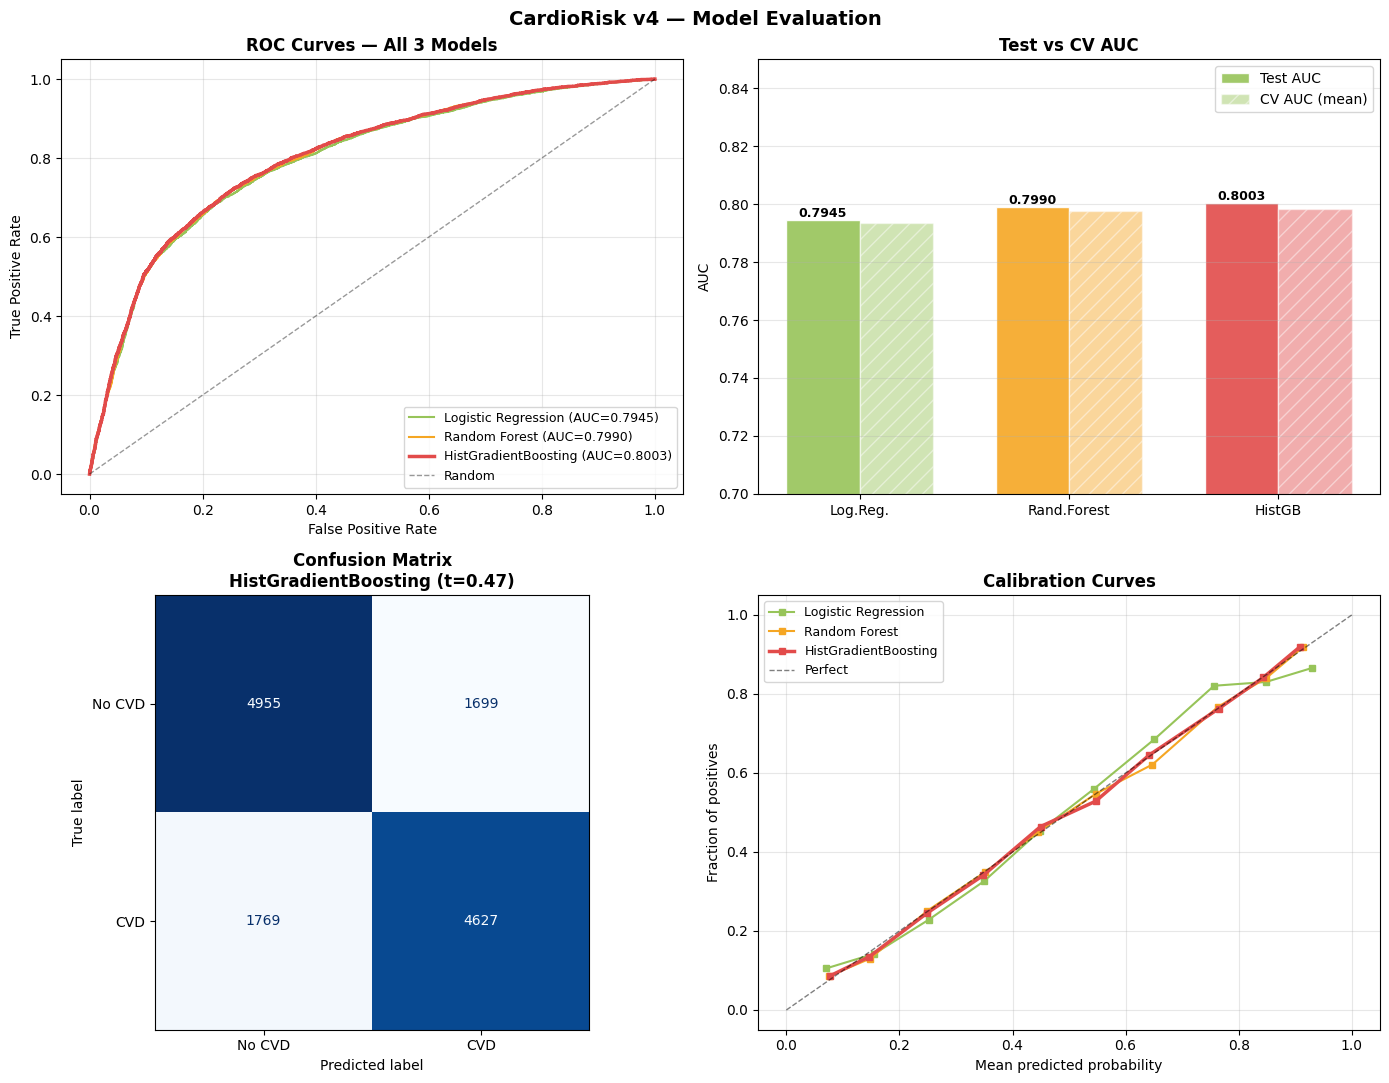

Saved: outputs\evaluation_plots.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("CardioRisk v4 — Model Evaluation", fontsize=14, fontweight="bold")

COLORS = {
    "Logistic Regression": "#97C459",
    "Random Forest": "#f5a623",
    "HistGradientBoosting": "#E24B4A",
}

# 1. ROC curves
ax = axes[0, 0]
for name, model in MODELS.items():
    probs_n = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs_n)
    auc_n = roc_auc_score(y_test, probs_n)
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ax.plot(fpr, tpr, color=COLORS[name], lw=lw, label=f"{name} (AUC={auc_n:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All 3 Models", fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

# 2. AUC bar chart (test vs CV)
ax = axes[0, 1]
names = list(MODELS.keys())
aucs_t = [roc_auc_score(y_test, MODELS[n].predict_proba(X_test)[:, 1]) for n in names]
aucs_c = [cv_results[n]["auc_mean"] for n in names]
x = np.arange(len(names))
w = 0.35
b1 = ax.bar(x - w/2, aucs_t, w, label="Test AUC",
            color=[COLORS[n] for n in names], alpha=0.9, edgecolor="white")
ax.bar(x + w/2, aucs_c, w, label="CV AUC (mean)",
       color=[COLORS[n] for n in names], alpha=0.45, edgecolor="white", hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(["Log.Reg.", "Rand.Forest", "HistGB"], fontsize=10)
ax.set_ylabel("AUC")
ax.set_ylim(0.70, 0.85)
ax.set_title("Test vs CV AUC", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, axis="y")
for b in b1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.001,
            f"{b.get_height():.4f}", ha="center", fontsize=9, fontweight="bold")

# 3. Confusion matrix
ax = axes[1, 0]
ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=["No CVD", "CVD"]).plot(
    ax=ax, colorbar=False, cmap="Blues", values_format="d"
)
ax.set_title(f"Confusion Matrix\n{BEST_MODEL_NAME} (t={OPT_THRESHOLD:.2f})", fontweight="bold")

# 4. Calibration curves
ax = axes[1, 1]
for name, model in MODELS.items():
    probs_n = model.predict_proba(X_test)[:, 1]
    pt, pp = calibration_curve(y_test, probs_n, n_bins=10, strategy="uniform")
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ax.plot(pp, pt, "s-", color=COLORS[name], lw=lw, markersize=5, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curves", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "evaluation_plots.png")

## Cell 15 — Precision–Recall and calibration diagnostics

This section complements ROC analysis with precision–recall performance and a dedicated calibration visualization for the selected model.

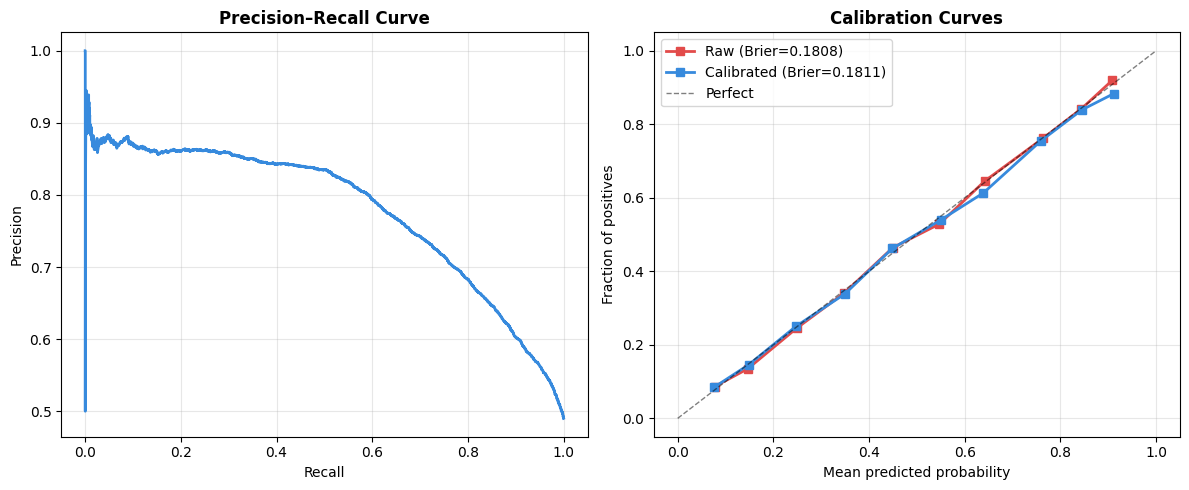

Saved: outputs\calibration_pr.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[0].plot(recall, precision, color="#378ADD", lw=2)
axes[0].set_title("Precision–Recall Curve", fontweight="bold")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(alpha=0.3)

# Raw vs calibrated
pt_raw, pp_raw = calibration_curve(y_test, y_proba, n_bins=10, strategy="uniform")
pt_cal, pp_cal = calibration_curve(y_test, cal_proba, n_bins=10, strategy="uniform")
axes[1].plot(pp_raw, pt_raw, "s-", color="#E24B4A", lw=2, label=f"Raw (Brier={brier:.4f})")
axes[1].plot(pp_cal, pt_cal, "s-", color="#378ADD", lw=2, label=f"Calibrated (Brier={brier_cal:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect")
axes[1].set_title("Calibration Curves", fontweight="bold")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction of positives")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calibration_pr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "calibration_pr.png")

## Cell 16 — Risk decile validation

Predicted risks are grouped into deciles to assess whether model probabilities preserve monotone ordering from lowest- to highest-risk groups.

Risk Decile Validation — HistGradientBoosting
Base CVD rate: 49.0%
decile    N     Range   CVD_pct  Lift
    D1 1305 0.03–0.16 10.881226  0.22
    D2 1311 0.16–0.23 20.213577  0.41
    D3 1302 0.23–0.29 25.422427  0.52
    D4 1303 0.29–0.37 33.077513  0.67
    D5 1304 0.37–0.45 39.110429  0.80
    D6 1305 0.45–0.55 51.570881  1.05
    D7 1305 0.55–0.73 60.306513  1.23
    D8 1305 0.73–0.82 79.463602  1.62
    D9 1305 0.82–0.85 84.137931  1.72
   D10 1305 0.85–0.93 85.977011  1.75

Monotone ordering: ✓ Yes
D10/D1 lift: 7.9x


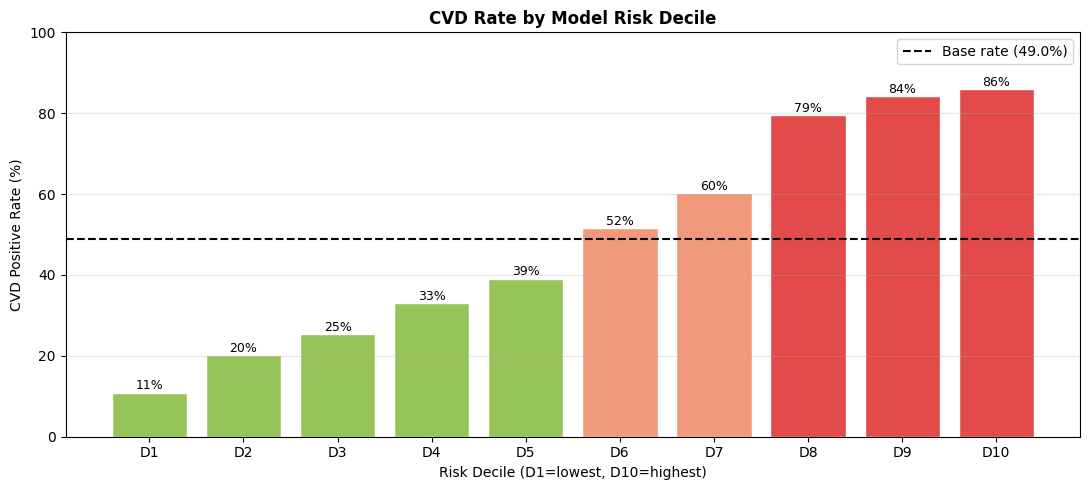

Saved: outputs\decile_chart.png


In [16]:
dec = pd.DataFrame({"prob": y_proba, "actual": y_test.values})
dec["decile"] = pd.qcut(dec["prob"], q=10, labels=[f"D{i}" for i in range(1, 11)])

summary = dec.groupby("decile", observed=True).agg(
    N=("actual", "count"),
    CVD_rate=("actual", "mean"),
    Score_min=("prob", "min"),
    Score_max=("prob", "max"),
).reset_index()

summary["CVD_pct"] = summary["CVD_rate"] * 100
summary["Lift"] = (summary["CVD_rate"] / y_test.mean()).round(2)
summary["Range"] = (
    summary["Score_min"].round(2).astype(str) + "–" +
    summary["Score_max"].round(2).astype(str)
)

print(f"Risk Decile Validation — {BEST_MODEL_NAME}")
print(f"Base CVD rate: {y_test.mean():.1%}")
print(summary[["decile", "N", "Range", "CVD_pct", "Lift"]].to_string(index=False))

rates = summary["CVD_rate"].values
mono = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
print(f"\nMonotone ordering: {'✓ Yes' if mono else '⚠ No'}")
print(f"D10/D1 lift: {rates[-1] / rates[0]:.1f}x")

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#97C459" if r < 0.50 else "#F0997B" if r < 0.70 else "#E24B4A"
          for r in summary["CVD_rate"]]
bars = ax.bar(summary["decile"], summary["CVD_pct"], color=colors, edgecolor="white")
ax.axhline(y_test.mean() * 100, color="black", ls="--", lw=1.5,
           label=f"Base rate ({y_test.mean():.1%})")
for b, v in zip(bars, summary["CVD_pct"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9)

ax.set_xlabel("Risk Decile (D1=lowest, D10=highest)")
ax.set_ylabel("CVD Positive Rate (%)")
ax.set_title("CVD Rate by Model Risk Decile", fontweight="bold")
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decile_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "decile_chart.png")

## Cell 17 — SHAP explainability

SHAP is used to quantify feature influence for the final tree-based model. The notebook generates both global and local explanation views.

Computing SHAP values...


 99%|===================| 12945/13050 [00:31<00:00]        C:\Users\hp\AppData\Local\Temp\ipykernel_29028\4018527670.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=16, show=False)


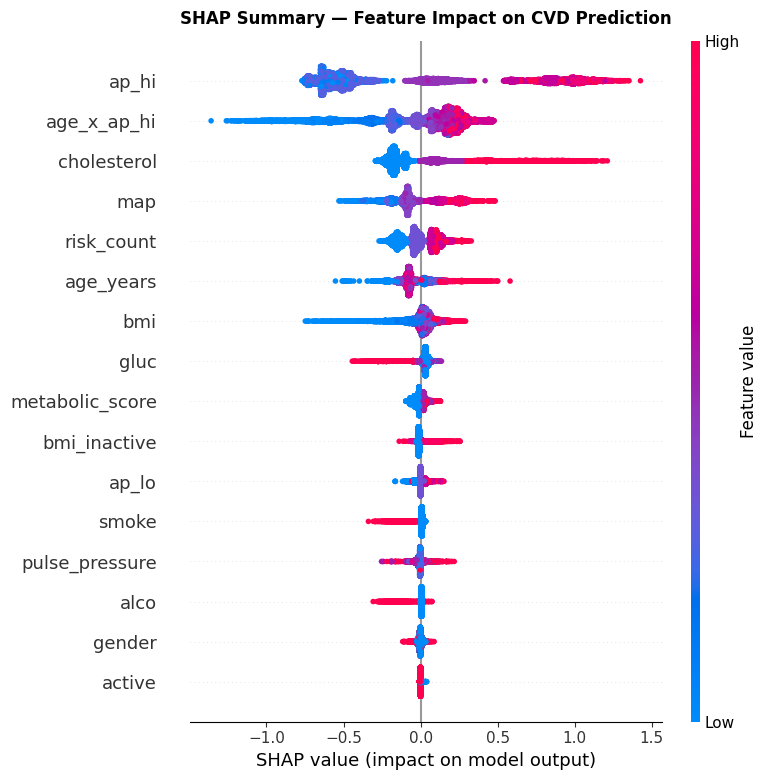

C:\Users\hp\AppData\Local\Temp\ipykernel_29028\4018527670.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=16, show=False)


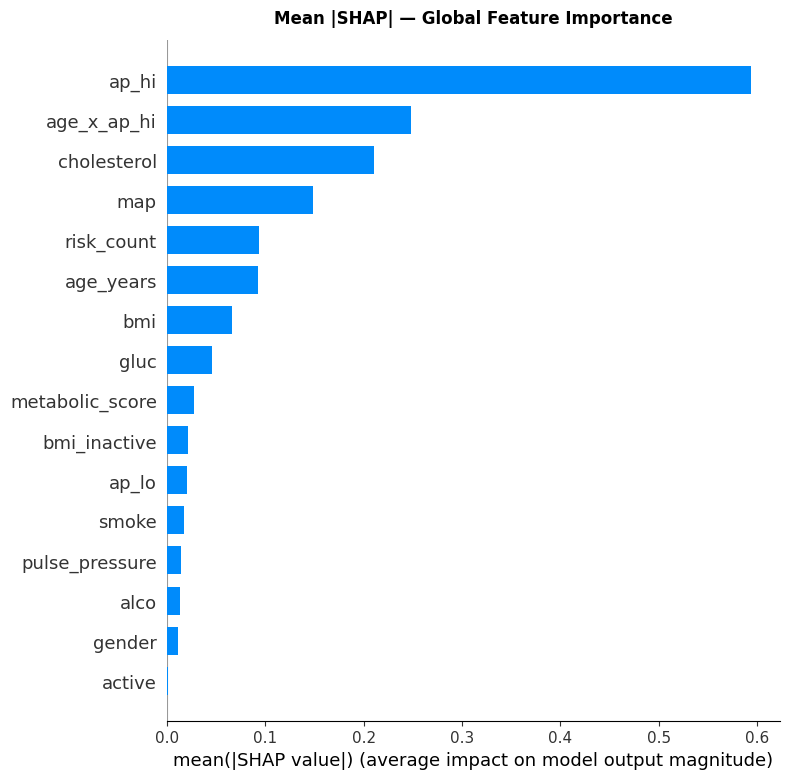

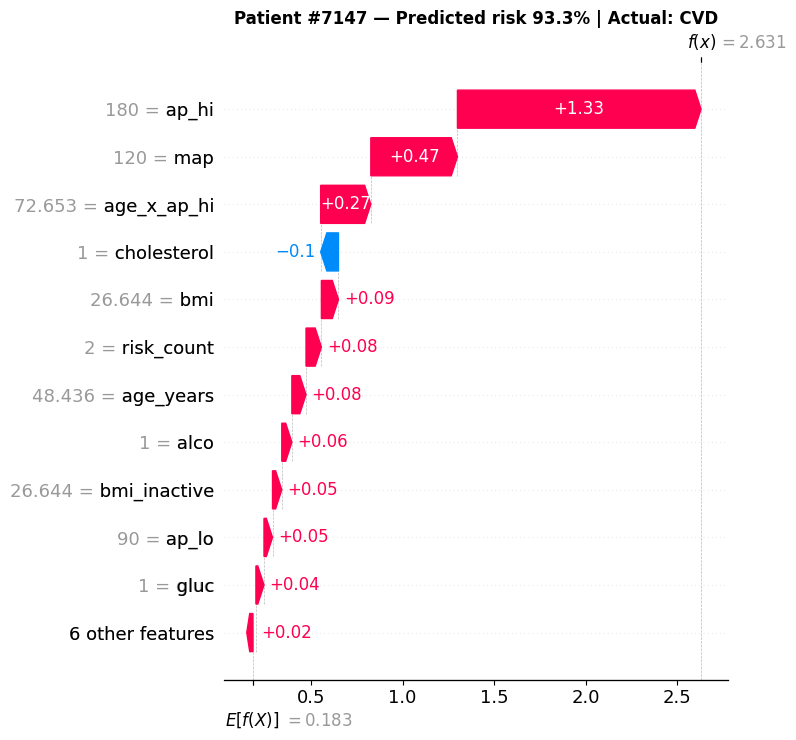


Feature importance (SHAP):
        Feature  Mean |SHAP|
          ap_hi       0.5934
    age_x_ap_hi       0.2480
    cholesterol       0.2104
            map       0.1484
     risk_count       0.0942
      age_years       0.0931
            bmi       0.0667
           gluc       0.0460
metabolic_score       0.0273
   bmi_inactive       0.0219
          ap_lo       0.0204
          smoke       0.0175
 pulse_pressure       0.0146
           alco       0.0133
         gender       0.0110
         active       0.0009
       hyp_flag       0.0000


In [18]:
print("Computing SHAP values...")

if BEST_MODEL_NAME == "HistGradientBoosting":
    shap_model = pipeline
else:
    shap_model = MODELS["HistGradientBoosting"].fit(X_train, y_train)

explainer = shap.Explainer(shap_model, X_train)
shap_values = explainer(X_test, check_additivity=False)

# 1. Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=16, show=False)
plt.title("SHAP Summary — Feature Impact on CVD Prediction", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Bar importance
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=16, show=False)
plt.title("Mean |SHAP| — Global Feature Importance", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Waterfall for highest-risk patient
idx = int(np.argmax(y_proba))
shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
plt.title(
    f"Patient #{idx} — Predicted risk {y_proba[idx]:.1%} | Actual: "
    f"{'CVD' if y_test.iloc[idx] else 'No CVD'}",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_patient.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Feature importance table
shap_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0),
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("\nFeature importance (SHAP):")
print(shap_imp.round(4).to_string(index=False))

SHAP_IMPORTANCES = dict(zip(shap_imp["Feature"], shap_imp["Mean |SHAP|"]))

## Cell 18 — Save model package

All artifacts required for deployment are stored in a single serialized package, including the fitted model, calibrator, selected features, threshold, and SHAP-based importance values.

In [19]:
model_meta = {
    "pipeline": pipeline,
    "calibrator": CALIBRATOR,
    "features": FEATURES,
    "best_model_name": BEST_MODEL_NAME,
    "shap_importances": SHAP_IMPORTANCES,
    "optimal_threshold": float(OPT_THRESHOLD),
    "auc": float(auc_score),
    "brier_raw": float(brier),
    "brier_calibrated": float(brier_cal),
    "cv_auc_mean": float(cv_results[BEST_MODEL_NAME]["auc_mean"]),
    "cv_auc_std": float(cv_results[BEST_MODEL_NAME]["auc_std"]),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "n_features": len(FEATURES),
    "threshold_screening": 0.35,
    "threshold_referral": 0.60,
    "model_version": "v4.0",
    "all_cv_results": cv_results,
}

MODEL_FILE = OUTPUT_DIR / "cardiorisk_model_v4.pkl"
with open(MODEL_FILE, "wb") as f:
    pickle.dump(model_meta, f)

print()
print("╔" + "═"*62 + "╗")
print("║ CardioRisk v4 — Complete" + " "*36 + "║")
print("╠" + "═"*62 + "╣")
print(f"║ Best model     : {BEST_MODEL_NAME:<39}║")
print(f"║ Test AUC       : {auc_score:.4f}" + " "*42 + "║")
print(f"║ CV AUC         : {cv_results[BEST_MODEL_NAME]['auc_mean']:.4f} ± {cv_results[BEST_MODEL_NAME]['auc_std']:.4f}" + " "*24 + "║")
print(f"║ Brier (raw)    : {brier:.4f}" + " "*42 + "║")
print(f"║ Brier (cal.)   : {brier_cal:.4f}" + " "*42 + "║")
print(f"║ Opt threshold  : {OPT_THRESHOLD:.3f}" + " "*42 + "║")
print(f"║ Features       : {len(FEATURES)}" + " "*47 + "║")
print(f"║ Train patients : {len(X_train):,}" + " "*40 + "║")
print("╠" + "═"*62 + "╣")
print(f"║ Saved package  : {MODEL_FILE.name:<39}║")
print("╠" + "═"*62 + "╣")
print("║ RESEARCH TOOL ONLY — NOT A DIAGNOSTIC DEVICE" + " "*14 + "║")
print("╚" + "═"*62 + "╝")


╔══════════════════════════════════════════════════════════════╗
║ CardioRisk v4 — Complete                                    ║
╠══════════════════════════════════════════════════════════════╣
║ Best model     : HistGradientBoosting                   ║
║ Test AUC       : 0.8003                                          ║
║ CV AUC         : 0.7984 ± 0.0046                        ║
║ Brier (raw)    : 0.1808                                          ║
║ Brier (cal.)   : 0.1811                                          ║
║ Opt threshold  : 0.465                                          ║
║ Features       : 17                                               ║
║ Train patients : 52,199                                        ║
╠══════════════════════════════════════════════════════════════╣
║ Saved package  : cardiorisk_model_v4.pkl                ║
╠══════════════════════════════════════════════════════════════╣
║ RESEARCH TOOL ONLY — NOT A DIAGNOSTIC DEVICE              ║
╚════════════════════

## Cell 19 — Generate the interactive Flask GUI

This cell writes a standalone `cardiorisk_gui.py` application that loads the saved model package and exposes a browser-based clinical decision-support interface.

In [24]:
"""
CardioRisk GUI — Refined Professional Edition
Usage:
    python cardiorisk_gui_refined.py
Needs:
    outputs/cardiorisk_model_v4.pkl
"""

import os
import time
import pickle
import threading
import webbrowser
import numpy as np
from flask import Flask, request, jsonify, render_template_string

BASE_DIR = os.getcwd()
MODEL_FILE = os.path.join(BASE_DIR, "outputs", "cardiorisk_model_v4.pkl")

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"Model not found: {MODEL_FILE}\nRun the notebook save-model cell first."
    )

with open(MODEL_FILE, "rb") as f:
    _meta = pickle.load(f)

PIPELINE = _meta["pipeline"]
CALIBRATOR = _meta["calibrator"]
FEATURES = _meta["features"]
AUC = _meta["auc"]
OPT_T = _meta["optimal_threshold"]
SHAP_IMP = _meta.get("shap_importances", {})
MODEL_NAME = _meta.get("best_model_name", "HistGradientBoosting")


def build_vector(age, gender, height, weight, ap_hi, ap_lo, chol, gluc, smoke, alco, active):
    ay = age / 365.0
    bmi = weight / ((height / 100.0) ** 2)
    pp = ap_hi - ap_lo
    row = {
        "age_years": ay,
        "bmi": bmi,
        "ap_hi": float(ap_hi),
        "ap_lo": float(ap_lo),
        "pulse_pressure": float(pp),
        "cholesterol": float(chol),
        "gluc": float(gluc),
        "smoke": float(smoke),
        "alco": float(alco),
        "active": float(active),
        "gender": float(gender),
        "map": ap_lo + pp / 3.0,
        "hyp_flag": 1.0 if ap_hi >= 140 else 0.0,
        "metabolic_score": float((bmi >= 30) + (gluc > 1) + (chol > 1)),
        "risk_count": float((ap_hi >= 140) + (ay >= 55) + (chol == 3) + (bmi >= 30) + (active == 0)),
        "age_x_ap_hi": ay * (ap_hi / 120.0),
        "bmi_inactive": bmi * (1.0 - active),
    }
    return np.array([[row.get(f, 0.0) for f in FEATURES]])


def get_tier(probability):
    pct = probability * 100
    if pct < 25:
        return (
            "LOW",
            "#22c55e",
            "Estimated cardiovascular risk is low. This result should be interpreted alongside routine clinical assessment and standard preventive counselling."
        )
    if pct < 50:
        return (
            "MODERATE",
            "#eab308",
            "Estimated cardiovascular risk is moderate. Follow-up evaluation may be considered in the context of broader clinical findings and patient history."
        )
    if pct < 75:
        return (
            "HIGH",
            "#f97316",
            "Estimated cardiovascular risk is high. This result may support further clinical review when interpreted with symptoms, examination findings, and clinician judgment."
        )
    return (
        "VERY HIGH",
        "#ef4444",
        "Estimated cardiovascular risk is very high. This estimate should not be interpreted in isolation and may warrant prompt clinical assessment depending on the full patient context."
    )


IMP = {
    "ap_hi": 0.70,
    "age_years": 0.14,
    "cholesterol": 0.08,
    "bmi": 0.04,
    "hyp_flag": 0.03,
    "risk_count": 0.02,
    "metabolic_score": 0.01,
    "ap_lo": 0.02,
    "pulse_pressure": 0.01,
    "gluc": 0.01,
    "active": 0.01,
}
if SHAP_IMP:
    IMP.update(SHAP_IMP)


HTML = r"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>CardioRisk — Clinical Decision Support</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&family=JetBrains+Mono:wght@400;500;700&display=swap" rel="stylesheet">
<style>
:root{
  --bg:#07111f;
  --surface:#0d1b2f;
  --surface-2:#11233c;
  --border:rgba(255,255,255,0.08);
  --border-strong:rgba(255,255,255,0.14);
  --text:#eaf2fb;
  --muted:#97a9c1;
  --subtle:#6f859f;
  --primary:#5ab2ff;
  --primary-soft:rgba(90,178,255,0.14);
  --accent:#8b7dff;
  --warning:#eab308;
  --orange:#f97316;
  --danger:#ef4444;
  --shadow:0 20px 50px rgba(0,0,0,0.28);
  --font:"Inter",system-ui,sans-serif;
  --mono:"JetBrains Mono",monospace;
}
*{box-sizing:border-box}
html,body{margin:0;padding:0}
body{
  font-family:var(--font);
  background:
    radial-gradient(circle at top left, rgba(90,178,255,0.08), transparent 28%),
    radial-gradient(circle at bottom right, rgba(139,125,255,0.07), transparent 30%),
    linear-gradient(180deg, var(--bg) 0%, #06101d 100%);
  color:var(--text);
  min-height:100vh;
}
.top-line{
  height:3px;
  background:linear-gradient(90deg, var(--primary), var(--accent), var(--primary));
  box-shadow:0 0 18px rgba(90,178,255,0.35);
}
.header{
  display:flex;
  justify-content:space-between;
  align-items:center;
  padding:18px 28px;
  border-bottom:1px solid var(--border);
  background:rgba(7,17,31,0.78);
  backdrop-filter:blur(14px);
  position:sticky;
  top:0;
  z-index:10;
}
.brand{display:flex;align-items:center;gap:14px}
.brand-icon{
  width:42px;height:42px;border-radius:14px;
  display:grid;place-items:center;
  background:linear-gradient(135deg, rgba(90,178,255,0.2), rgba(139,125,255,0.16));
  border:1px solid rgba(255,255,255,0.08);
  box-shadow:inset 0 1px 0 rgba(255,255,255,0.06), 0 10px 26px rgba(0,0,0,0.2);
  font-size:19px;
}
.brand-name{font-size:1.15rem;font-weight:800;letter-spacing:-0.02em}
.brand-sub{font-size:0.74rem;color:var(--muted);letter-spacing:0.08em;text-transform:uppercase}
.header-meta{display:flex;gap:12px;flex-wrap:wrap}
.meta-chip{
  padding:8px 12px;border-radius:999px;background:rgba(255,255,255,0.04);
  border:1px solid var(--border);color:var(--muted);font-size:0.72rem;font-family:var(--mono)
}
.meta-chip strong{color:var(--text)}
.banner{
  margin:18px auto 0;
  max-width:1280px;
  padding:10px 18px;
  border:1px solid rgba(234,179,8,0.18);
  border-radius:14px;
  background:rgba(234,179,8,0.06);
  color:#f8d67a;
  font-size:0.82rem;
  line-height:1.6;
}
.layout{
  max-width:1280px;
  margin:18px auto 28px;
  padding:0 18px;
  display:grid;
  grid-template-columns:400px 1fr;
  gap:18px;
  align-items:start
}
@media(max-width:1024px){.layout{grid-template-columns:1fr}}
.panel{
  background:linear-gradient(180deg, rgba(13,27,47,0.95), rgba(10,22,40,0.95));
  border:1px solid var(--border);
  border-radius:24px;
  box-shadow:var(--shadow);
  overflow:hidden
}
.panel-header{
  padding:16px 20px;
  border-bottom:1px solid var(--border);
  display:flex;
  align-items:center;
  justify-content:space-between;
  background:rgba(255,255,255,0.02)
}
.panel-title{
  display:flex;
  align-items:center;
  gap:10px;
  font-size:0.8rem;
  letter-spacing:0.14em;
  text-transform:uppercase;
  color:var(--muted);
  font-weight:700
}
.dot{
  width:8px;height:8px;border-radius:999px;
  background:var(--primary);
  box-shadow:0 0 12px var(--primary)
}
.panel-body{padding:20px}
.section-title{
  margin:20px 0 10px;
  color:var(--primary);
  font-size:0.72rem;
  font-weight:800;
  letter-spacing:0.14em;
  text-transform:uppercase
}
.section-title:first-child{margin-top:0}
.grid-two{display:grid;grid-template-columns:1fr 1fr;gap:10px}
.field{display:flex;flex-direction:column;gap:6px}
.field label{
  font-size:0.68rem;
  font-weight:700;
  color:var(--muted);
  letter-spacing:0.04em;
  text-transform:uppercase
}
.field .unit{color:var(--subtle);font-size:0.62rem}
input,select{
  width:100%;
  padding:12px 13px;
  border-radius:14px;
  border:1px solid var(--border);
  background:linear-gradient(180deg, var(--surface-2), var(--surface));
  color:var(--text);
  font-size:0.92rem;
  outline:none;
  transition:0.2s ease
}
input::placeholder{color:var(--subtle)}
input:focus,select:focus{
  border-color:rgba(90,178,255,0.4);
  box-shadow:0 0 0 4px rgba(90,178,255,0.09)
}
button{
  width:100%;
  margin-top:18px;
  padding:14px 16px;
  border:none;
  border-radius:16px;
  font-family:var(--font);
  font-weight:800;
  letter-spacing:0.1em;
  text-transform:uppercase;
  color:white;
  cursor:pointer;
  background:linear-gradient(135deg, var(--primary), var(--accent));
  box-shadow:0 14px 28px rgba(90,178,255,0.22);
  transition:transform .16s ease, box-shadow .16s ease, opacity .16s ease
}
button:hover{
  transform:translateY(-1px);
  box-shadow:0 18px 34px rgba(90,178,255,0.26)
}
.helper{
  margin-top:14px;
  font-size:0.8rem;
  color:var(--muted);
  line-height:1.7
}
.metrics-strip{
  padding:14px 20px;
  border-top:1px solid var(--border);
  display:flex;
  gap:16px;
  flex-wrap:wrap;
  color:var(--muted);
  font-size:0.72rem;
  font-family:var(--mono)
}
.empty{
  min-height:520px;
  display:grid;
  place-items:center;
  text-align:center;
  color:var(--subtle);
  padding:40px 24px
}
.empty .icon{font-size:50px;opacity:.16}
.empty p{max-width:280px;line-height:1.8;font-size:0.86rem}
.result-wrap{
  padding:22px;
  display:none;
  flex-direction:column;
  gap:16px
}
.hero{
  display:grid;
  grid-template-columns:145px 1fr;
  gap:20px;
  align-items:center;
  padding:20px;
  background:linear-gradient(180deg, rgba(255,255,255,0.03), rgba(255,255,255,0.015));
  border:1px solid var(--border);
  border-radius:22px
}
@media(max-width:760px){.hero{grid-template-columns:1fr;text-align:center}}
.gauge{position:relative;width:132px;height:132px;margin:auto}
.gauge svg{width:132px;height:132px;display:block}
.g-track{fill:none;stroke:rgba(255,255,255,0.08);stroke-width:10}
.g-fill{
  fill:none;
  stroke:var(--primary);
  stroke-width:10;
  stroke-linecap:round;
  transform:rotate(-90deg);
  transform-origin:66px 66px;
  stroke-dasharray:339.292;
  stroke-dashoffset:339.292;
  transition:stroke-dashoffset 1s ease, stroke .25s ease
}
.g-center{
  position:absolute;
  inset:0;
  display:grid;
  place-items:center
}
.g-number{font-size:2rem;font-weight:800;letter-spacing:-0.04em}
.g-label{
  font-size:0.7rem;
  color:var(--muted);
  text-transform:uppercase;
  letter-spacing:0.12em
}
.risk-pill{
  display:inline-flex;
  align-items:center;
  gap:8px;
  padding:8px 14px;
  border-radius:999px;
  border:1px solid var(--border-strong);
  font-size:0.74rem;
  font-weight:800;
  letter-spacing:0.1em;
  text-transform:uppercase;
  margin-bottom:10px;
  background:rgba(255,255,255,0.03)
}
.interpretation-title{
  color:var(--muted);
  font-size:0.68rem;
  letter-spacing:0.12em;
  text-transform:uppercase;
  font-weight:800;
  margin-bottom:8px;
}
.hero-text{
  color:var(--muted);
  line-height:1.8;
  font-size:0.92rem
}
.helper-note{
  margin-top:10px;
  font-size:0.78rem;
  color:var(--muted);
  line-height:1.6;
}
.cards{display:grid;grid-template-columns:repeat(3,1fr);gap:10px}
@media(max-width:800px){.cards{grid-template-columns:repeat(2,1fr)}}
@media(max-width:560px){.cards{grid-template-columns:1fr}}
.card{
  background:linear-gradient(180deg, var(--surface-2), var(--surface));
  border:1px solid var(--border);
  border-radius:18px;
  padding:14px
}
.card .k{
  color:var(--muted);
  font-size:0.68rem;
  text-transform:uppercase;
  letter-spacing:0.1em;
  margin-bottom:8px;
  font-weight:700
}
.card .v{font-size:1.02rem;font-weight:800}
.card .s{margin-top:4px;color:var(--subtle);font-size:0.76rem}
.block{
  background:linear-gradient(180deg, var(--surface-2), var(--surface));
  border:1px solid var(--border);
  border-radius:18px;
  padding:16px
}
.block-title{
  color:var(--muted);
  font-size:0.7rem;
  text-transform:uppercase;
  letter-spacing:0.12em;
  font-weight:800;
  margin-bottom:12px
}
.bar-row{display:flex;align-items:center;gap:10px;margin-bottom:9px}
.bar-row:last-child{margin-bottom:0}
.bar-name{
  width:110px;
  flex-shrink:0;
  color:var(--muted);
  font-size:0.75rem;
  text-transform:capitalize
}
.bar-track{
  flex:1;
  height:8px;
  border-radius:999px;
  background:rgba(255,255,255,0.06);
  overflow:hidden
}
.bar-fill{
  height:100%;
  border-radius:999px;
  background:linear-gradient(90deg, var(--primary), var(--accent));
  transition:width .8s ease
}
.bar-val{
  width:42px;
  text-align:right;
  font-family:var(--mono);
  color:var(--text);
  font-size:0.72rem
}
.table-wrap{overflow:auto}
table{width:100%;border-collapse:collapse;font-size:0.78rem}
th,td{
  padding:10px 12px;
  text-align:left;
  border-top:1px solid var(--border)
}
th{
  color:var(--muted);
  font-size:0.68rem;
  text-transform:uppercase;
  letter-spacing:0.08em;
  background:rgba(255,255,255,0.02)
}
tr.active-row td{background:var(--primary-soft);color:var(--text)}
.warning{
  border:1px solid rgba(234,179,8,0.22);
  background:rgba(234,179,8,0.07);
  color:#f6d37a;
  border-radius:16px;
  padding:14px;
  line-height:1.7;
  font-size:0.84rem
}
.footer{
  max-width:1280px;
  margin:0 auto 26px;
  padding:0 18px;
  color:var(--subtle);
  font-size:0.72rem;
  display:flex;
  justify-content:space-between;
  gap:12px;
  flex-wrap:wrap
}
</style>
</head>
<body>
<div class="top-line"></div>

<header class="header">
  <div class="brand">
    <div class="brand-icon">♥</div>
    <div>
      <div class="brand-name">CardioRisk</div>
      <div class="brand-sub">Clinical Decision Support · Research Edition</div>
    </div>
  </div>
  <div class="header-meta">
    <div class="meta-chip">System <strong>Ready</strong></div>
    <div class="meta-chip">AUC <strong id="hdrAuc">—</strong></div>
    <div class="meta-chip">Model <strong id="hdrModel">—</strong></div>
  </div>
</header>

<div class="banner">
  <strong>Research tool only.</strong>
  This interface provides a statistical cardiovascular risk estimate for academic use and must not be interpreted as a diagnosis, treatment recommendation, or substitute for clinician judgment.
</div>

<div class="layout">
  <section class="panel">
    <div class="panel-header">
      <div class="panel-title"><span class="dot"></span>Patient Examination Data</div>
    </div>
    <div class="panel-body">
      <div class="section-title">Anthropometrics</div>
      <div class="grid-two">
        <div class="field">
          <label>Age <span class="unit">years</span></label>
          <input type="number" id="age" placeholder="54" min="18" max="100" step="0.5">
        </div>
        <div class="field">
          <label>Gender</label>
          <select id="gender">
            <option value="1">Female</option>
            <option value="2">Male</option>
          </select>
        </div>
        <div class="field">
          <label>Height <span class="unit">cm</span></label>
          <input type="number" id="height" placeholder="168" min="100" max="220">
        </div>
        <div class="field">
          <label>Weight <span class="unit">kg</span></label>
          <input type="number" id="weight" placeholder="74" min="30" max="250">
        </div>
      </div>

      <div class="section-title">Blood Pressure</div>
      <div class="grid-two">
        <div class="field">
          <label>Systolic <span class="unit">mmHg</span></label>
          <input type="number" id="ap_hi" placeholder="130" min="70" max="250">
        </div>
        <div class="field">
          <label>Diastolic <span class="unit">mmHg</span></label>
          <input type="number" id="ap_lo" placeholder="85" min="40" max="200">
        </div>
      </div>

      <div class="section-title">Laboratory Findings</div>
      <div class="grid-two">
        <div class="field">
          <label>Cholesterol</label>
          <select id="cholesterol">
            <option value="1">Normal</option>
            <option value="2">Above Normal</option>
            <option value="3">Well Above Normal</option>
          </select>
        </div>
        <div class="field">
          <label>Glucose</label>
          <select id="gluc">
            <option value="1">Normal</option>
            <option value="2">Above Normal</option>
            <option value="3">Well Above Normal</option>
          </select>
        </div>
      </div>

      <div class="section-title">Lifestyle Factors</div>
      <div class="grid-two">
        <div class="field">
          <label>Smoking</label>
          <select id="smoke">
            <option value="0">Non-smoker</option>
            <option value="1">Current smoker</option>
          </select>
        </div>
        <div class="field">
          <label>Alcohol Use</label>
          <select id="alco">
            <option value="0">None / minimal</option>
            <option value="1">Regular</option>
          </select>
        </div>
        <div class="field" style="grid-column:1/-1">
          <label>Physical Activity</label>
          <select id="active">
            <option value="1">Active (≥3× / week)</option>
            <option value="0">Sedentary</option>
          </select>
        </div>
      </div>

      <button id="calcBtn" onclick="calculate()">Compute Risk Score</button>

      <div class="helper">
        This interface estimates cardiovascular risk using non-invasive variables only. It is designed for educational and research presentation, not for direct diagnosis.
      </div>
    </div>

    <div class="metrics-strip" id="metricsStrip"></div>
  </section>

  <section class="panel">
    <div class="panel-header">
      <div class="panel-title"><span class="dot"></span>Risk Assessment Output</div>
    </div>

    <div class="empty" id="emptyState">
      <div>
        <div class="icon">♥</div>
        <p>Enter the patient data on the left and press <strong>Compute Risk Score</strong> to generate the model output.</p>
      </div>
    </div>

    <div class="result-wrap" id="resultWrap">
      <div class="hero">
        <div class="gauge">
          <svg viewBox="0 0 132 132">
            <circle class="g-track" cx="66" cy="66" r="54"></circle>
            <circle class="g-fill" id="gFill" cx="66" cy="66" r="54"></circle>
          </svg>
          <div class="g-center">
            <div>
              <div class="g-number" id="gNumber">—</div>
              <div class="g-label">Risk %</div>
            </div>
          </div>
        </div>
        <div>
          <div class="risk-pill" id="riskPill">— Risk</div>
          <div class="interpretation-title">Clinical Interpretation</div>
          <div class="hero-text" id="heroText">—</div>
          <div class="helper-note">
            This output is a statistical risk estimate, not a diagnosis or treatment recommendation.
          </div>
        </div>
      </div>

      <div class="cards" id="cardsGrid"></div>

      <div class="block">
        <div class="block-title">Probability Comparison</div>
        <div id="probabilityBars"></div>
      </div>

      <div class="block">
        <div class="block-title">Feature Contributions — Global SHAP Importance</div>
        <div id="shapBars"></div>
      </div>

      <div class="block table-wrap">
        <div class="block-title">Clinical Operating Thresholds</div>
        <table>
          <thead>
            <tr>
              <th>Mode</th>
              <th>Threshold</th>
              <th>Sensitivity</th>
              <th>Specificity</th>
              <th>Application</th>
            </tr>
          </thead>
          <tbody id="thresholdBody"></tbody>
        </table>
      </div>

      <div id="warningBox"></div>
    </div>
  </section>
</div>

<div class="footer">
  <div>CardioRisk — No-Blood-Test CVD Screening · Refined UI</div>
  <div id="footerDate"></div>
</div>

<script>
const THRESHOLDS = [
  {mode:"Population Screening", t:0.35, sens:"~83%", spec:"~59%", use:"Maximise case detection"},
  {mode:"Balanced", t:0.47, sens:"~73%", spec:"~74%", use:"Accuracy-optimal operating point"},
  {mode:"Default", t:0.50, sens:"~69%", spec:"~78%", use:"Standard binary classification"},
  {mode:"Referral Triage", t:0.60, sens:"~60%", spec:"~85%", use:"Minimise unnecessary referrals"}
];

(async()=>{
  try{
    const h = await (await fetch("/health")).json();
    document.getElementById("hdrAuc").textContent = h.auc.toFixed(4);
    document.getElementById("hdrModel").textContent = h.model_name;
    document.getElementById("metricsStrip").innerHTML = `
      <div>Algorithm <strong>${h.model_name}</strong></div>
      <div>Test AUC <strong>${h.auc.toFixed(4)}</strong></div>
      <div>Features <strong>${h.n_features}</strong></div>
    `;
  }catch(e){}
  document.getElementById("footerDate").textContent =
    new Date().toLocaleDateString("en-GB",{day:"numeric",month:"long",year:"numeric"});
})();

function setGauge(percent,color){
  const circle = document.getElementById("gFill");
  const circumference = 339.292;
  const offset = circumference * (1 - percent/100);
  circle.style.strokeDashoffset = offset;
  circle.style.stroke = color;
  document.getElementById("gNumber").textContent = Math.round(percent);
  document.getElementById("gNumber").style.color = color;

  const pill = document.getElementById("riskPill");
  pill.style.color = color;
  pill.style.borderColor = color;
  pill.style.background = "rgba(255,255,255,0.03)";
}

function renderCards(d){
  const bpColor =
    d.bp_label.includes("Stage 2") ? "var(--danger)" :
    d.bp_label.includes("Stage 1") ? "var(--orange)" :
    d.bp_label.includes("Elevated") ? "var(--warning)" :
    "var(--text)";

  const bmiColor =
    d.bmi_label === "Obese" ? "var(--danger)" :
    d.bmi_label === "Overweight" ? "var(--orange)" :
    "var(--text)";

  const ppWarn = d.pulse_pressure > 60;

  document.getElementById("cardsGrid").innerHTML = `
    <div class="card">
      <div class="k">BMI</div>
      <div class="v" style="color:${bmiColor}">${d.bmi}</div>
      <div class="s">${d.bmi_label}</div>
    </div>
    <div class="card">
      <div class="k">BP Classification</div>
      <div class="v" style="font-size:.9rem;color:${bpColor}">${d.bp_label}</div>
      <div class="s">${d._ap_hi}/${d._ap_lo} mmHg</div>
    </div>
    <div class="card">
      <div class="k">Pulse Pressure</div>
      <div class="v" style="color:${ppWarn ? "var(--orange)" : "var(--text)"}">${d.pulse_pressure} mmHg</div>
      <div class="s">${ppWarn ? "Widened pulse pressure" : "Within expected range"}</div>
    </div>
    <div class="card">
      <div class="k">Age-Cohort Baseline</div>
      <div class="v" style="color:var(--primary)">${d.age_cohort_rate}%</div>
      <div class="s">Population baseline</div>
    </div>
    <div class="card">
      <div class="k">Optimal Threshold</div>
      <div class="v" style="color:var(--primary)">${d.threshold}</div>
      <div class="s">Selected operating point</div>
    </div>
    <div class="card">
      <div class="k">Model AUC</div>
      <div class="v" style="color:var(--primary)">${d.model_auc}</div>
      <div class="s">Held-out test performance</div>
    </div>
  `;
}

function renderProbabilityBars(d){
  const calibrated = (d.probability * 100).toFixed(1);
  const raw = (d.raw_probability * 100).toFixed(1);

  document.getElementById("probabilityBars").innerHTML = `
    <div class="bar-row">
      <div class="bar-name">Calibrated</div>
      <div class="bar-track"><div class="bar-fill" style="width:${calibrated}%"></div></div>
      <div class="bar-val">${calibrated}%</div>
    </div>
    <div class="bar-row">
      <div class="bar-name">Raw model</div>
      <div class="bar-track"><div class="bar-fill" style="width:${raw}%;opacity:.55"></div></div>
      <div class="bar-val">${raw}%</div>
    </div>
  `;
}

function renderShapBars(data){
  const pairs = Object.entries(data).sort((a,b)=>b[1]-a[1]).slice(0,8);
  const maxVal = pairs[0]?.[1] || 1;
  document.getElementById("shapBars").innerHTML = pairs.map(([name,val]) => `
    <div class="bar-row">
      <div class="bar-name">${name.replaceAll("_"," ")}</div>
      <div class="bar-track"><div class="bar-fill" style="width:${(val/maxVal*100).toFixed(1)}%"></div></div>
      <div class="bar-val">${(val*100).toFixed(0)}%</div>
    </div>
  `).join("");
}

function renderThresholds(prob){
  document.getElementById("thresholdBody").innerHTML = THRESHOLDS.map(row => {
    const active = prob >= row.t - 0.06 && prob < row.t + 0.06;
    return `
      <tr class="${active ? "active-row" : ""}">
        <td>${row.mode}</td>
        <td>${row.t.toFixed(2)}</td>
        <td>${row.sens}</td>
        <td>${row.spec}</td>
        <td>${row.use}</td>
      </tr>
    `;
  }).join("");
}

function renderWarnings(warnings){
  const box = document.getElementById("warningBox");
  if(!warnings || !warnings.length){
    box.innerHTML = "";
    return;
  }
  box.innerHTML = `
    <div class="warning">
      <strong>Data quality notes</strong><br>
      ${warnings.map(w => `• ${w}`).join("<br>")}
    </div>
  `;
}

async function calculate(){
  const payload = {
    age: parseFloat(document.getElementById("age").value),
    gender: parseInt(document.getElementById("gender").value),
    height: parseFloat(document.getElementById("height").value),
    weight: parseFloat(document.getElementById("weight").value),
    ap_hi: parseFloat(document.getElementById("ap_hi").value),
    ap_lo: parseFloat(document.getElementById("ap_lo").value),
    cholesterol: parseInt(document.getElementById("cholesterol").value),
    gluc: parseInt(document.getElementById("gluc").value),
    smoke: parseInt(document.getElementById("smoke").value),
    alco: parseInt(document.getElementById("alco").value),
    active: parseInt(document.getElementById("active").value)
  };

  const btn = document.getElementById("calcBtn");
  btn.disabled = true;
  btn.style.opacity = 0.8;
  btn.textContent = "Calculating...";

  try{
    const res = await fetch("/predict", {
      method:"POST",
      headers:{"Content-Type":"application/json"},
      body:JSON.stringify(payload)
    });

    const d = await res.json();
    if(!res.ok) throw new Error(d.error || "Server error");

    d._ap_hi = payload.ap_hi;
    d._ap_lo = payload.ap_lo;

    document.getElementById("emptyState").style.display = "none";
    document.getElementById("resultWrap").style.display = "flex";

    setGauge(d.percent, d.tier_color);
    document.getElementById("riskPill").textContent = d.tier_label + " RISK";
    document.getElementById("heroText").textContent = d.tier_action;

    renderCards(d);
    renderProbabilityBars(d);
    renderShapBars(d.shap_importances || {});
    renderThresholds(d.probability);
    renderWarnings(d.data_quality);
  }catch(err){
    document.getElementById("emptyState").style.display = "grid";
    document.getElementById("emptyState").innerHTML = `
      <div>
        <div class="icon">⚠</div>
        <p>${err.message}</p>
      </div>
    `;
    document.getElementById("resultWrap").style.display = "none";
  }finally{
    btn.disabled = false;
    btn.style.opacity = 1;
    btn.textContent = "Compute Risk Score";
  }
}
</script>
</body>
</html>
"""

app = Flask(__name__)

@app.route("/")
def index():
    return render_template_string(HTML)

@app.route("/health")
def health():
    return jsonify({
        "status": "ok",
        "auc": round(AUC, 4),
        "n_features": len(FEATURES),
        "model_name": MODEL_NAME
    })

@app.route("/predict", methods=["POST"])
def predict():
    try:
        d = request.get_json(force=True)

        age = float(d["age"])
        gender = int(d["gender"])
        height = float(d["height"])
        weight = float(d["weight"])
        ap_hi = float(d["ap_hi"])
        ap_lo = float(d["ap_lo"])
        cholesterol = int(d["cholesterol"])
        gluc = int(d["gluc"])
        smoke = int(d.get("smoke", 0))
        alco = int(d.get("alco", 0))
        active = int(d.get("active", 1))

        bmi = round(weight / ((height / 100) ** 2), 1)
        pulse_pressure = int(ap_hi - ap_lo)

        flags = []
        if not (70 <= ap_hi <= 250):
            flags.append(f"Systolic BP {ap_hi:.0f} mmHg outside expected range (70–250)")
        if not (40 <= ap_lo <= 200):
            flags.append(f"Diastolic BP {ap_lo:.0f} mmHg outside expected range (40–200)")
        if ap_hi <= ap_lo:
            flags.append("Systolic BP must exceed diastolic BP")
        if not (100 <= height <= 220):
            flags.append(f"Height {height:.0f} cm outside expected range (100–220)")
        if not (30 <= weight <= 250):
            flags.append(f"Weight {weight:.0f} kg outside expected range (30–250)")
        if not (18 <= age <= 100):
            flags.append(f"Age {age:.0f} outside validated range (18–100)")

        X = build_vector(age, gender, height, weight, ap_hi, ap_lo, cholesterol, gluc, smoke, alco, active)
        raw_prob = float(PIPELINE.predict_proba(X)[0, 1])
        cal_prob = float(CALIBRATOR.predict_proba(X)[0, 1])

        tier_label, tier_color, tier_action = get_tier(cal_prob)

        bmi_label = (
            "Underweight" if bmi < 18.5 else
            "Normal weight" if bmi < 25 else
            "Overweight" if bmi < 30 else
            "Obese"
        )

        bp_label = (
            "Hypertensive crisis" if ap_hi >= 180 else
            "Stage 2 hypertension" if ap_hi >= 140 else
            "Stage 1 hypertension" if ap_hi >= 130 else
            "Elevated" if ap_hi >= 120 else
            "Normal"
        )

        age_cohort = round(next(
            r for a, r in [(40,.245),(45,.301),(50,.428),(55,.459),(60,.559),(100,.666)]
            if age < a
        ) * 100)

        shap_out = dict(sorted(IMP.items(), key=lambda x: -x[1]))

        return jsonify({
            "probability": round(cal_prob, 4),
            "raw_probability": round(raw_prob, 4),
            "percent": round(cal_prob * 100),
            "tier_label": tier_label,
            "tier_color": tier_color,
            "tier_action": tier_action,
            "bmi": bmi,
            "bmi_label": bmi_label,
            "pulse_pressure": pulse_pressure,
            "bp_label": bp_label,
            "age_cohort_rate": age_cohort,
            "data_quality": flags,
            "model_auc": round(AUC, 4),
            "threshold": round(OPT_T, 3),
            "features_used": FEATURES,
            "shap_importances": shap_out
        })
    except KeyError as e:
        return jsonify({"error": f"Missing field: {e}"}), 400
    except Exception as e:
        return jsonify({"error": str(e)}), 500

PORT = 5000

def _run():
    app.run(host="0.0.0.0", port=PORT, debug=False, use_reloader=False)

if __name__ == "__main__":
    print(f"CardioRisk running at http://localhost:{PORT}")
    threading.Thread(
        target=lambda: (time.sleep(1.0), webbrowser.open(f"http://localhost:{PORT}")),
        daemon=True
    ).start()
    _run()

CardioRisk running at http://localhost:5000
 * Serving Flask app '__main__'
 * Debug mode: off


INFO - WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.0.113:5000
INFO - Press CTRL+C to quit
INFO - 127.0.0.1 - - [17/Apr/2026 20:03:46] "GET / HTTP/1.1" 200 -
INFO - 127.0.0.1 - - [17/Apr/2026 20:03:46] "GET /health HTTP/1.1" 200 -
c:\Users\hp\Downloads\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\Downloads\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\hp\Downloads\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was

## Cell 20 — GUI launch instructions

The graphical interface can be launched after the model package has been saved and the GUI file has been generated.

In [ ]:
print("Run the GUI using one of the following:")
print("1) Terminal / VS Code:")
print("   python cardiorisk_gui.py")
print()
print("2) From a notebook cell:")
print("   exec(open('cardiorisk_gui.py', encoding='utf-8').read())")